**CAKE DATASET**

# **ANALYSIS OF DATA**

**LOAD DATASET**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
data = pd.read_csv('/content/5579 Vedant Surve.csv')

**CHECKING AND DATASET AND INFORMATION**



In [ ]:
data.shape

(105, 9)

In [ ]:
data.head(5)

,sr.no,Weight (grams),Price (INR),Calories,Flavor,Type,Occasion,Frosting,Dietary Restriction
0,1,500,800,2000,Chocolate,Sponge,Birthday,Buttercream,Gluten-Free
1,2,750,1200,3000,Vanilla,Layer,Wedding,Fondant,NaN
2,3,450,600,1800,Strawberry,Cheesecake,Casual,Whipped Cream,Vegan
3,4,1000,1500,4000,Red Velvet,Layer,Anniversary,Cream Cheese,NaN
4,5,300,500,1200,Mango,Sponge,Party,Buttercream,Sugar-Free


In [ ]:
data.tail(5)

,sr.no,Weight (grams),Price (INR),Calories,Flavor,Type,Occasion,Frosting,Dietary Restriction
100,101,1247,2708,1328,Coffee,Mousse,Casual,Buttercream,Vegan
101,102,1053,1084,2889,Mango,Sponge,Birthday,Cream Cheese,NaN
102,103,580,701,4510,Butterscotch,Layer,Wedding,No Frosting,Vegan
103,104,1145,1741,4586,Strawberry,Cheesecake,Anniversary,Buttercream,Gluten-Free
104,105,1041,1179,3816,Pineapple,Layer,Casual,No Frosting,Nut-Free


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   sr.no                105 non-null    int64 
 1   Weight (grams)       105 non-null    int64 
 2   Price (INR)          105 non-null    int64 
 3   Calories             105 non-null    int64 
 4   Flavor               105 non-null    object
 5   Type                 105 non-null    object
 6   Occasion             105 non-null    object
 7   Frosting             105 non-null    object
 8   Dietary Restriction  79 non-null     object
dtypes: int64(4), object(5)
memory usage: 7.5+ KB


In [ ]:
data.columns

Index(['sr.no', 'Weight (grams)', 'Price (INR)', 'Calories', 'Flavor', 'Type ',
       'Occasion', 'Frosting', 'Dietary Restriction'],
      dtype='object')

In [ ]:
data.dtypes

,0
sr.no,int64
Weight (grams),int64
Price (INR),int64
Calories,int64
Flavor,object
Type,object
Occasion,object
Frosting,object
Dietary Restriction,object


In [ ]:
# 1. Relationship between cake weight and price (correlation)
correlation_weight_price = data['Weight (grams)'].corr(data['Price (INR)'])
print("1. Correlation between cake weight and price:", correlation_weight_price)

1. Correlation between cake weight and price: 0.08495186961695896


In [ ]:
# 2. Calorie counts by cake type (mean calories per type)
calories_by_type = data.groupby('Type ') ['Calories'].mean()
print("\n2. Average calorie counts by cake type:")
print(calories_by_type)


2. Average calorie counts by cake type:
Type 
Bundt         3098.157895
Cheesecake    3057.888889
Cupcake       2990.550000
Layer         3567.333333
Mousse        3361.315789
Sponge        3324.272727
Name: Calories, dtype: float64


In [ ]:
# 3. Highest and lowest average calorie count by flavor
average_calories_by_flavor = data.groupby('Flavor')['Calories'].mean()
highest_calorie_flavor = average_calories_by_flavor.idxmax()
lowest_calorie_flavor = average_calories_by_flavor.idxmin()
print("\n3. Flavor with highest average calories:", highest_calorie_flavor)
print("Flavor with lowest average calories:", lowest_calorie_flavor)


3. Flavor with highest average calories: Red Velvet
Flavor with lowest average calories: Mango


In [ ]:
# 4. Average price by frosting type
average_price_by_frosting = data.groupby('Frosting')['Price (INR)'].mean()
print("\n4. Average price by frosting type:")
print(average_price_by_frosting)


4. Average price by frosting type:
Frosting
Buttercream      1586.083333
Cream Cheese     1595.950000
Fondant          1629.428571
Ganache          1225.875000
No Frosting      1455.500000
Whipped Cream    1731.541667
Name: Price (INR), dtype: float64


In [ ]:
# 5. Percentage of cakes suitable for dietary restrictions
dietary_restrictions = data['Dietary Restriction'].value_counts(normalize=True) * 100
print("\n5. Percentage of cakes suitable for dietary restrictions:")
print(dietary_restrictions)


5. Percentage of cakes suitable for dietary restrictions:
Dietary Restriction
Gluten-Free    29.113924
Vegan          24.050633
Sugar-Free     24.050633
Nut-Free       22.784810
Name: proportion, dtype: float64


In [ ]:
# 6. Cake weight by occasion (average weight per occasion)
average_weight_by_occasion = data.groupby('Occasion')['Weight (grams)'].mean()
print("\n6. Average cake weight by occasion:")
print(average_weight_by_occasion)


6. Average cake weight by occasion:
Occasion
Anniversary    904.714286
Birthday       916.000000
Casual         878.000000
Festival       955.562500
Party          813.473684
Wedding        980.095238
Name: Weight (grams), dtype: float64


In [ ]:
# 7. Average calorie count for sugar-free vs. non-sugar-free cakes
sugar_free_avg_calories = data[data['Dietary Restriction'] == 'Sugar-Free']['Calories'].mean()
non_sugar_free_avg_calories = data[data['Dietary Restriction'] != 'Sugar-Free']['Calories'].mean()
print("\n7. Average calories for sugar-free cakes:", sugar_free_avg_calories)
print("Average calories for non-sugar-free cakes:", non_sugar_free_avg_calories)


7. Average calories for sugar-free cakes: 3456.0
Average calories for non-sugar-free cakes: 3170.906976744186


In [ ]:
# 8. Occasion with the highest priced cakes on average
average_price_by_occasion = data.groupby('Occasion')['Price (INR)'].mean()
highest_priced_occasion = average_price_by_occasion.idxmax()
print("\n8. Occasion with highest average cake price:", highest_priced_occasion)
print("Average price:", average_price_by_occasion[highest_priced_occasion])


8. Occasion with highest average cake price: Anniversary
Average price: 1855.0


In [ ]:
# 9. Relationship between frosting type and cake calories (average calories per frosting type)
average_calories_by_frosting = data.groupby('Frosting')['Calories'].mean()
print("\n9. Average calories by frosting type:")
print(average_calories_by_frosting)


9. Average calories by frosting type:
Frosting
Buttercream      3128.250000
Cream Cheese     3430.550000
Fondant          3316.571429
Ganache          2954.750000
No Frosting      3137.600000
Whipped Cream    3173.916667
Name: Calories, dtype: float64


In [ ]:
# 10. Difference in weight and price by frosting type (average values)
average_weight_price_by_frosting = data.groupby('Frosting')[['Weight (grams)', 'Price (INR)']].mean()
print("\n10. Average weight and price by frosting type:")
print(average_weight_price_by_frosting)


10. Average weight and price by frosting type:
               Weight (grams)  Price (INR)
Frosting                                  
Buttercream        814.416667  1586.083333
Cream Cheese      1004.650000  1595.950000
Fondant            961.047619  1629.428571
Ganache            737.000000  1225.875000
No Frosting        900.900000  1455.500000
Whipped Cream      884.041667  1731.541667


# **Visualization Of Data**

<ipython-input-18-3a2157ebf374>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Type ', y='Price (INR)', palette='pastel')


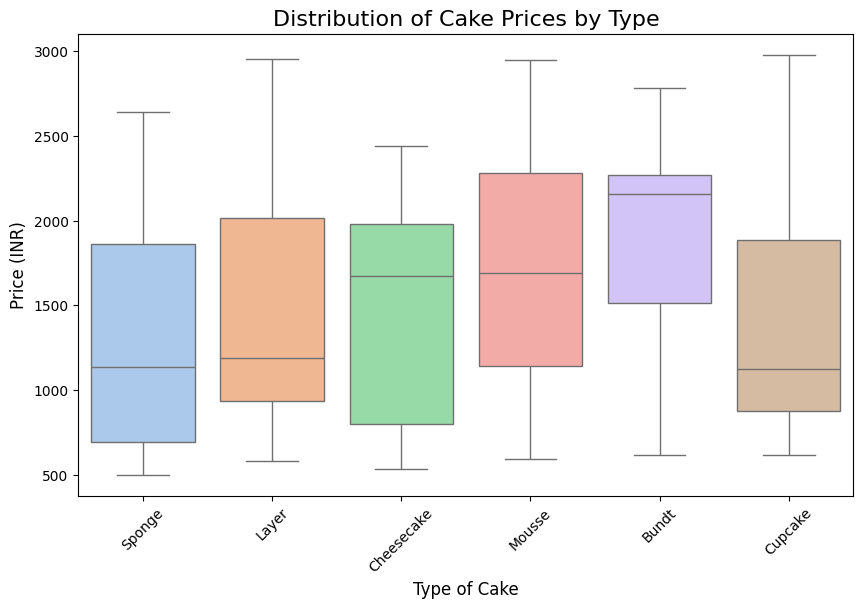

In [ ]:
# 1. Distribution of cake prices across different types of cakes
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Type ', y='Price (INR)', palette='pastel')
plt.title('Distribution of Cake Prices by Type', fontsize=16)
plt.xlabel('Type of Cake', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-19-adb2dccbdcbe>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='Occasion', y='Weight (grams)', palette='muted', ci=None)
<ipython-input-19-adb2dccbdcbe>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Occasion', y='Weight (grams)', palette='muted', ci=None)


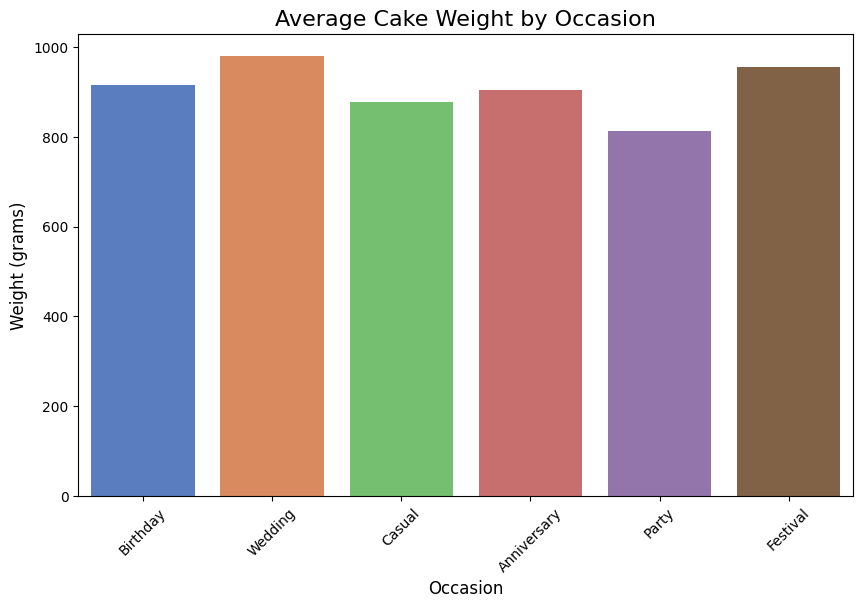

In [ ]:
# 2. Cake weight by occasion
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='Occasion', y='Weight (grams)', palette='muted', ci=None)
plt.title('Average Cake Weight by Occasion', fontsize=16)
plt.xlabel('Occasion', fontsize=12)
plt.ylabel('Weight (grams)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-20-bf81d506a977>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Frosting', y='Calories', palette='coolwarm')


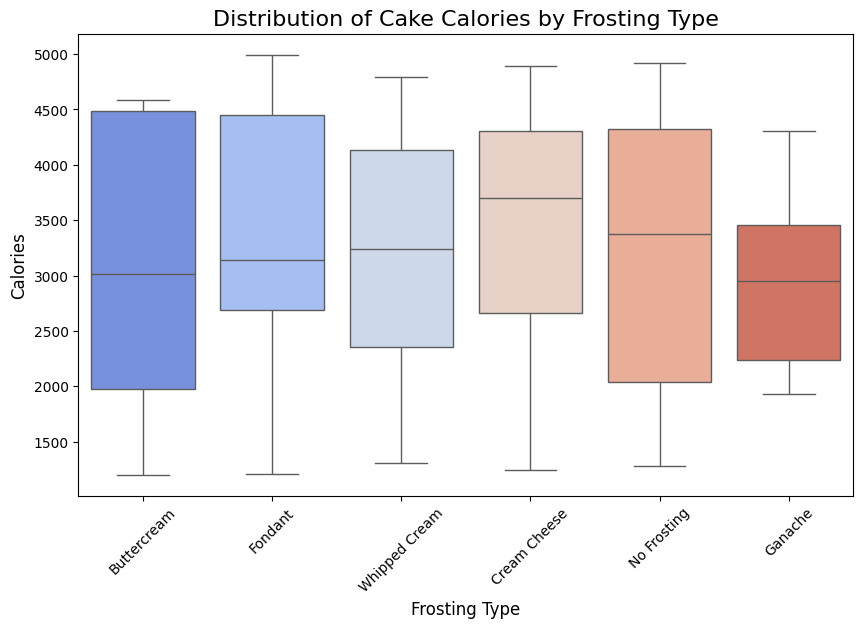

In [ ]:
# 3. Distribution of cake calories across different frosting types
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Frosting', y='Calories', palette='coolwarm')
plt.title('Distribution of Cake Calories by Frosting Type', fontsize=16)
plt.xlabel('Frosting Type', fontsize=12)
plt.ylabel('Calories', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-21-910883df355e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Dietary Restriction', y='Price (INR)', palette='Set2')


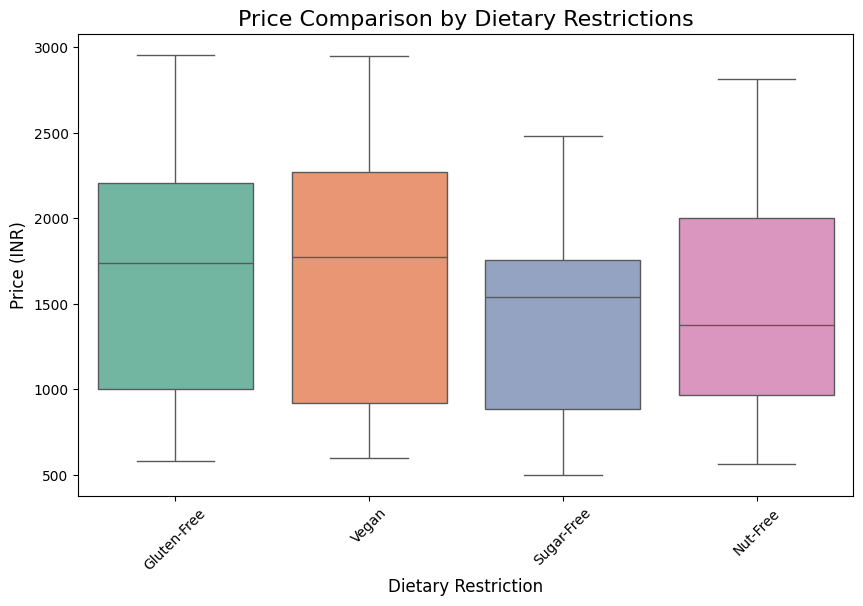

In [ ]:
# 4. Comparison of prices for cakes with dietary restrictions
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Dietary Restriction', y='Price (INR)', palette='Set2')
plt.title('Price Comparison by Dietary Restrictions', fontsize=16)
plt.xlabel('Dietary Restriction', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-22-059addf0d21c>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_calories_frosting, x='Frosting', y='Calories', palette='viridis')


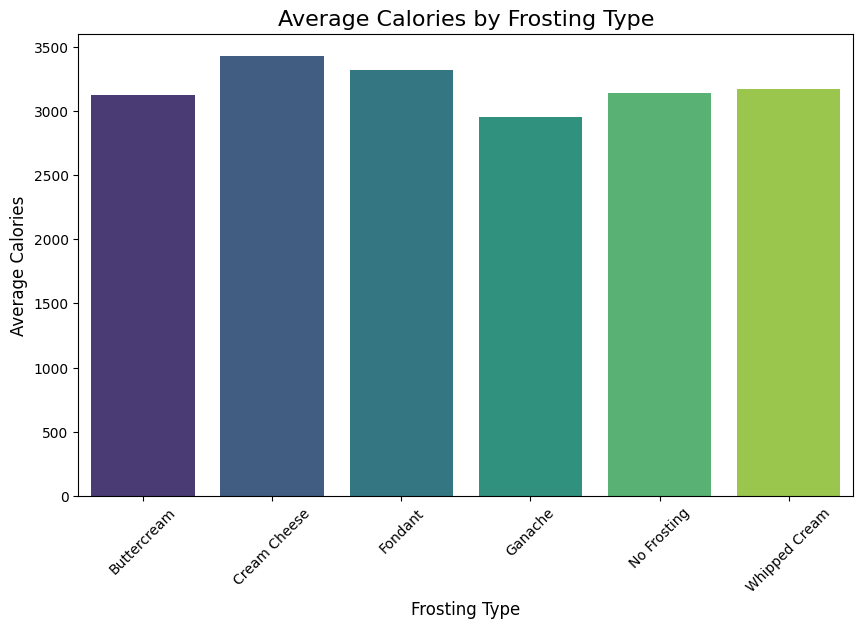

In [ ]:
# 5. Average calorie count for cakes with different frosting types
plt.figure(figsize=(10, 6))
average_calories_frosting = data.groupby('Frosting')['Calories'].mean().reset_index()
sns.barplot(data=average_calories_frosting, x='Frosting', y='Calories', palette='viridis')
plt.title('Average Calories by Frosting Type', fontsize=16)
plt.xlabel('Frosting Type', fontsize=12)
plt.ylabel('Average Calories', fontsize=12)
plt.xticks(rotation=45)
plt.show()


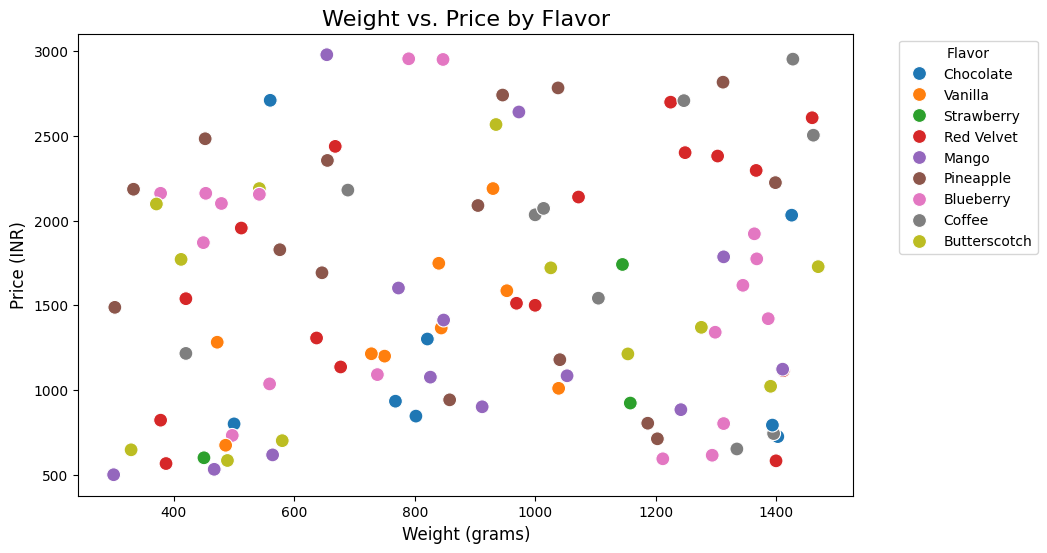

In [ ]:
# 6. Comparison of weight and price by cake flavors
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Weight (grams)', y='Price (INR)', hue='Flavor', palette='tab10', s=100)
plt.title('Weight vs. Price by Flavor', fontsize=16)
plt.xlabel('Weight (grams)', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(title='Flavor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<ipython-input-24-6dd4f481a04f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Frosting', y='Price (INR)', palette='plasma')


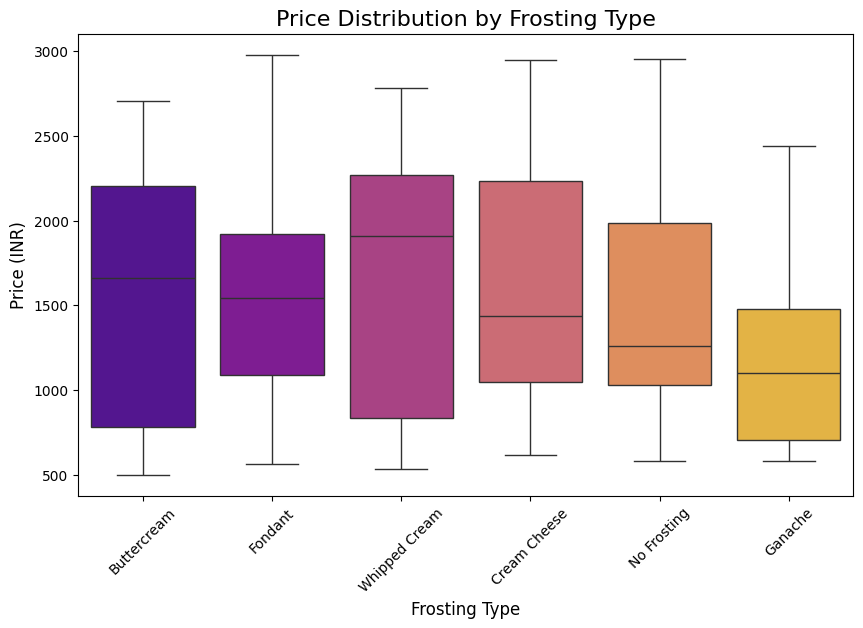

In [ ]:
# 7. Price distribution for cakes with and without frosting
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Frosting', y='Price (INR)', palette='plasma')
plt.title('Price Distribution by Frosting Type', fontsize=16)
plt.xlabel('Frosting Type', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-25-9396052902a3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Dietary Restriction', y='Calories', palette='cool')


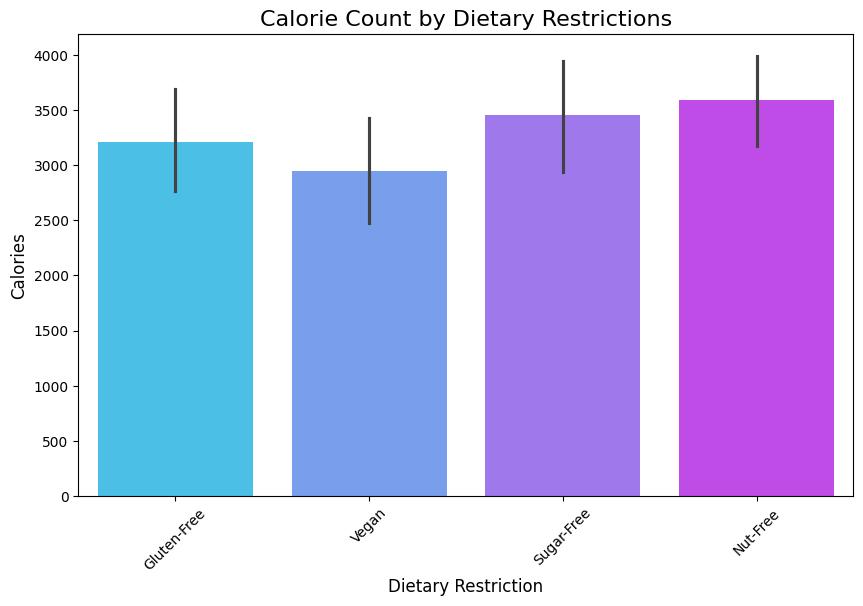

In [ ]:
# 8. Calorie count comparison by dietary restrictions
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='Dietary Restriction', y='Calories', palette='cool')
plt.title('Calorie Count by Dietary Restrictions', fontsize=16)
plt.xlabel('Dietary Restriction', fontsize=12)
plt.ylabel('Calories', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-26-ea1da313bedd>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_calories_type, x='Type ', y='Calories', palette='cubehelix')


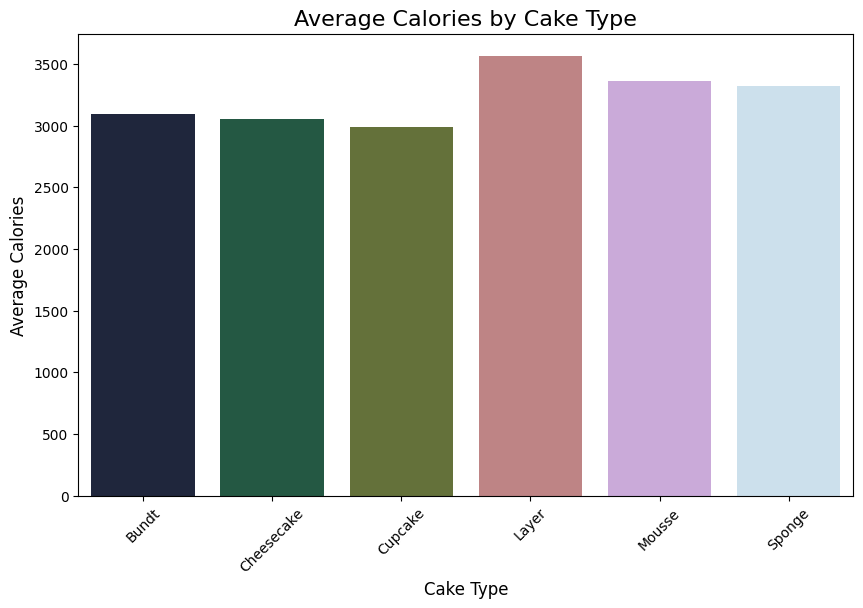

In [ ]:
# 9. Average calorie count by cake type
plt.figure(figsize=(10, 6))
average_calories_type = data.groupby('Type ')['Calories'].mean().reset_index()
sns.barplot(data=average_calories_type, x='Type ', y='Calories', palette='cubehelix')
plt.title('Average Calories by Cake Type', fontsize=16)
plt.xlabel('Cake Type', fontsize=12)
plt.ylabel('Average Calories', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-27-eb6175fdb758>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_price_occasion, x='Occasion', y='Price (INR)', palette='autumn')


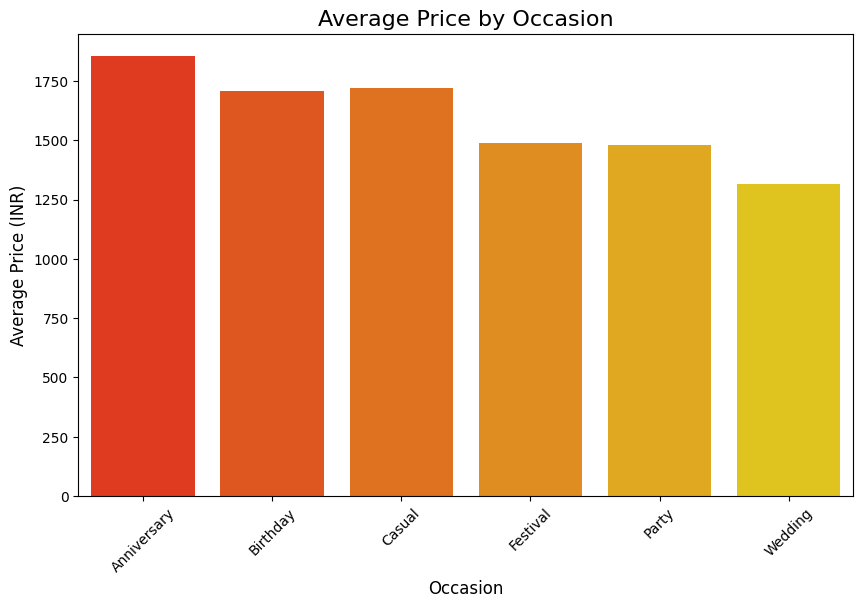

In [ ]:
# 10. Average price by occasion
plt.figure(figsize=(10, 6))
average_price_occasion = data.groupby('Occasion')['Price (INR)'].mean().reset_index()
sns.barplot(data=average_price_occasion, x='Occasion', y='Price (INR)', palette='autumn')
plt.title('Average Price by Occasion', fontsize=16)
plt.xlabel('Occasion', fontsize=12)
plt.ylabel('Average Price (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()